# Классификация изображений с помощью предварительно обученной нейронной сети ResNet

Чтобы запускать и редактировать код, сохраните копию этого ноутбука себе (Файл -> Создать копию на Диске). Свою копию вы сможете изменять и запускать.

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

<a target="_blank" href="https://colab.research.google.com/github/sozykin/dlpython_course/blob/master/pretrained_networks/pytorch/resnet_pretrained.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [19]:
from torchvision.io import read_image
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
%matplotlib inline

## Загружаем предварительно обученную модель

In [38]:
# Веса, обученные на наборе данных ImageNet
weights = ResNet50_Weights.IMAGENET1K_V2
# Создаем модель с предварительно обученными весами
model = resnet50(weights=weights)

Переключаем модель в режим распознавания

In [39]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Готовим инструменты предварительной обработки изображения

Каждая предварительно обученная нейронная сеть требует своей предварительной обработки.

In [40]:
preprocess = weights.transforms()

In [41]:
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

## Загружаем изображение

In [42]:
img = read_image("../plane.jpg")

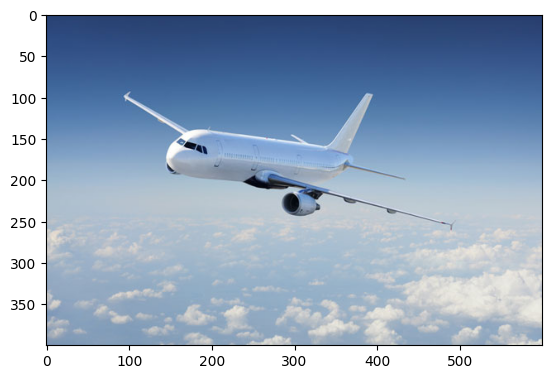

In [43]:
plt.imshow(img.permute(1, 2, 0) )

## Выполняем предварительную обработку изображения

In [44]:
img

tensor([[[ 40,  40,  40,  ...,  39,  39,  39],
         [ 40,  40,  40,  ...,  39,  39,  39],
         [ 40,  40,  40,  ...,  39,  39,  39],
         ...,
         [127, 127, 127,  ..., 226, 226, 217],
         [126, 126, 126,  ..., 218, 233, 225],
         [125, 125, 125,  ..., 201, 223, 221]],

        [[ 66,  66,  66,  ...,  61,  61,  61],
         [ 66,  66,  66,  ...,  61,  61,  61],
         [ 66,  66,  66,  ...,  61,  61,  61],
         ...,
         [151, 151, 151,  ..., 222, 220, 211],
         [149, 149, 149,  ..., 217, 229, 221],
         [148, 148, 148,  ..., 200, 222, 220]],

        [[115, 115, 115,  ..., 110, 110, 110],
         [115, 115, 115,  ..., 110, 110, 110],
         [115, 115, 115,  ..., 110, 110, 110],
         ...,
         [179, 179, 179,  ..., 221, 224, 215],
         [180, 180, 180,  ..., 215, 230, 222],
         [179, 179, 179,  ..., 196, 218, 215]]], dtype=torch.uint8)

In [45]:
batch = preprocess(img).unsqueeze(0)

In [46]:
batch

tensor([[[[-1.4158, -1.4158, -1.4158,  ..., -1.4158, -1.4158, -1.4158],
          [-1.4329, -1.4329, -1.4329,  ..., -1.4329, -1.4329, -1.4329],
          [-1.4158, -1.4158, -1.4158,  ..., -1.4158, -1.4158, -1.4158],
          ...,
          [ 0.0741,  0.0741,  0.0741,  ...,  0.4679,  0.5707,  0.7248],
          [ 0.0912,  0.0912,  0.0741,  ...,  0.4337,  0.6392,  0.9132],
          [ 0.0741,  0.0741,  0.0741,  ...,  0.3823,  0.6221,  0.9303]],

         [[-0.8803, -0.8803, -0.8803,  ..., -0.8978, -0.8978, -0.8978],
          [-0.8803, -0.8803, -0.8803,  ..., -0.8627, -0.8627, -0.8627],
          [-0.8627, -0.8627, -0.8627,  ..., -0.8452, -0.8452, -0.8452],
          ...,
          [ 0.6779,  0.6779,  0.6779,  ...,  0.9755,  1.0455,  1.1155],
          [ 0.6954,  0.6954,  0.6954,  ...,  0.9580,  1.0980,  1.2381],
          [ 0.6779,  0.6779,  0.6779,  ...,  0.9230,  1.0455,  1.2206]],

         [[ 0.1825,  0.1825,  0.1825,  ...,  0.1476,  0.1476,  0.1476],
          [ 0.1999,  0.1999,  

## Выполняем классификацию изображения

Выполняем распознавание

In [47]:
prediction = model(batch).squeeze(0).softmax(0)

Результаты распознавания

In [48]:
prediction

tensor([4.1709e-04, 3.7207e-04, 4.0890e-04, 7.0328e-04, 9.7529e-04, 6.1125e-04,
        2.9732e-04, 3.1718e-04, 4.3193e-04, 4.4811e-04, 3.7355e-04, 4.4168e-04,
        4.0933e-04, 3.4345e-04, 4.3721e-04, 3.4764e-04, 3.8944e-04, 2.8292e-04,
        2.9220e-04, 4.0550e-04, 4.8235e-04, 5.1648e-04, 2.4334e-04, 3.4344e-04,
        3.5758e-04, 4.9537e-04, 5.3898e-04, 3.5841e-04, 3.1242e-04, 4.7315e-04,
        3.4426e-04, 3.9101e-04, 4.4097e-04, 3.7009e-04, 2.8958e-04, 4.5157e-04,
        3.9501e-04, 3.2130e-04, 4.4786e-04, 6.3733e-04, 4.5207e-04, 3.7389e-04,
        4.0175e-04, 4.5282e-04, 4.9906e-04, 4.5522e-04, 3.9732e-04, 4.3415e-04,
        5.6226e-04, 3.3288e-04, 4.3923e-04, 6.4230e-04, 4.0466e-04, 3.9987e-04,
        3.9830e-04, 3.8343e-04, 3.0578e-04, 4.2672e-04, 3.5723e-04, 3.6055e-04,
        4.2940e-04, 3.7179e-04, 3.7526e-04, 3.3097e-04, 4.8604e-04, 3.1067e-04,
        6.1308e-04, 3.8814e-04, 3.3054e-04, 5.0142e-04, 3.9763e-04, 2.6811e-04,
        3.9675e-04, 5.4863e-04, 4.1032e-

Выбираем класс с максимальной вероятностью

In [49]:
class_id = prediction.argmax().item()

In [50]:
class_id

404

Получаем название класса

In [51]:
category_name = weights.meta["categories"][class_id]

In [52]:
category_name

'airliner'

Определяем вероятность принадлежности объекта данному классу

In [53]:
score = prediction[class_id].item()

In [54]:
score

0.36179834604263306

Печатаем результаты распознавания

In [55]:
print(f"{category_name}: {100 * score:.1f}%")

airliner: 36.2%
